# Financial HW2

**Objectives:**
- Collect **daily** stock prices and **daily** returns for the 30 stocks in the Dow Jones Industrial Average (DJIA)
- Rank these 30 stock components of the DJIA by most significant to be predicted with ARCH/GARCH modeling
    - *Use Lagrange Multipler Lag 1 test p-values for ranking*
- Create 5 models to **predict volatility** from the **top 5 most significant components** of the DJIA
    - GARCH(1,1) - Normal
    - t-GARCH(1,1)
    - QGARCH(1,1) - Normal
    - QGARCH(1,1) - t
- Forecast the next 30 days of volatility for each of the 5 models
- Rank the top 5 stocks by order of *most likely to be bothered by a market shock today*
- Rank the top 5 stocks by order of *longest effect a shock lasts*
    - Compare this to previous ranking and interpret

### Setup

In [1]:
# load libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import yfinance as yf

from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from arch import arch_model

### Daily Stock Prices & Returns

**Option 1:** reading in data from URL and transforming

In [4]:
# All 30 stocks according to https://www.fool.com/investing/stock-market/indexes/dow-jones/
DJIA_TICKERS = [
    "MMM", "AMZN", "AXP", "AMGN", "AAPL", "BA", "CAT", "CVX",
    "CSCO", "KO", "DIS", "GS", "HD", "HON", "IBM", "JNJ", "JPM",
    "MCD", "MRK", "MSFT", "NKE", "NVDA", "PG", "CRM", "SHW", "TRV",
    "UNH", "VZ", "V", "WMT"
]

In [ ]:
START  = "2011-02-28" # IMPORTANT: Start at 02-28 so that we have returns starting on the 03-01
END    = "2024-03-24"

# Pull data
raw = yf.download(
    DJIA_TICKERS,
    start=START,
    end=END,
    auto_adjust=True,
    progress=False
)

prices = raw["Close"].dropna(how="all")

simple_return = prices.pct_change() # create a new var for simple returns

prices.head()

prices_tidy = ( # get prices in a tidy format
    prices
    .stack()
    .rename("price")
    .reset_index()
    .rename(columns={"level_1": "ticker"})
)

returns_tidy = ( # get returns in a tidy format
    simple_return
    .stack()
    .rename("return")
    .reset_index()
    .rename(columns={"level_1": "ticker"})
)

data = prices_tidy.merge( # combine both returns and prices
    returns_tidy,
    on=["Date", "Ticker"],
    how="inner"
)[30:] # Drop the first 30 to ensure we start on march the first with the returns.
       # If not youd start on Feb 28 with NaNs on the return.This goes back to the
       # comment near the line of code: START  = "2011-02-28"

data['log_ret'] = (
    np.log(data["price"])
    .groupby(data["Ticker"])
    .diff()
)

data = data.dropna()

data


**Option 2:** reading in from static CSV (use if downloads fail from the last chunk)

In [2]:
# Assuming stocks.csv (from Google Drive) has been saved in the same directory as this notebook
data = pd.read_csv('stocks.csv')

# Adding column 'log_ret'
data['log_ret'] = (
    np.log(data["price"])
    .groupby(data["Ticker"])
    .diff()
)

data = data.dropna()

### Ranking (ARCH/GARCH Modeling)

In [5]:
all_stocks = []

for ticker in DJIA_TICKERS:

    filtered_df = data[data['Ticker']==ticker]
    y = filtered_df["log_ret"]

    # Using Lagrange Multipler Lag 1 test for p-values
    LM_LAGS = 1
    lm_stat, lm_pvalue, f_stat, f_pvalue = het_arch(y, maxlag=LM_LAGS)

    all_stocks.append({
        "ticker": ticker,
        "chi_square_stat": lm_stat,
        "chi_square_p_value": lm_pvalue,
        "f_test_stat": f_stat,
        "f_test_p_value": f_pvalue
    })

all_stocks = pd.DataFrame(all_stocks)
all_stocks.sort_values(by='chi_square_p_value', ascending=True)

,ticker,chi_square_stat,chi_square_p_value,f_test_stat,f_test_p_value
11,GS,595.989636,1.247642e-131,727.591979,6.334095e-145
13,HON,591.745416,1.045339e-130,721.272577,8.461964e-144
22,PG,581.830053,1.499713e-128,706.586468,3.553820e-141
16,JPM,562.966366,1.902557e-124,678.941869,3.273892e-136
19,MSFT,484.416227,2.337716e-107,567.829848,6.718462e-116
5,BA,404.125363,6.964765e-90,460.515414,1.038009e-95
25,TRV,403.008364,1.219151e-89,459.064623,1.964010e-95
26,UNH,336.130300,4.442592e-75,374.203615,4.850124e-79
15,JNJ,275.243604,8.168240e-62,300.223557,1.985998e-64
2,AXP,262.545720,4.782116e-59,285.170558,2.038862e-61


In [6]:
top_5_tickers = ['GS','HON','PG','JPM','MSFT']

### Model Creation

In [ ]:
for ticker in top_5_tickers:

    #get a df with only the data on that specific ticker
    filtered_data = data[data['Ticker']==ticker]

    #print what ticker we are fitting
    print(ticker)

    #create holdout dataset
    y_all = (filtered_data["log_ret"] * 100).copy()
    split_idx = len(y_all) - 252 #252 is about 1 trading year
    y_train = y_all.iloc[:split_idx]
    y_test  = y_all.iloc[split_idx:]

    train_dates = y_train.index
    test_dates  = y_test.index

    #create the models
    models = {
        # GARCH normal: simpler but underestimates extreme moves
        "GARCH_normal": arch_model(
            y_all, mean="Constant", vol="GARCH", p=1, q=1, dist="normal", rescale=False
        ),
        # GARCH-t: better for risk, allows for fatter tails
        "GARCH_t": arch_model(
            y_all, mean="Constant", vol="GARCH", p=1, q=1, dist="t", rescale=False
        ),
        "EGARCH_t": arch_model(
            y_all, mean="Constant", vol="EGARCH", p=1, q=1, dist="t", rescale=False
        ),
        "GJR-GARCH_t": arch_model(
            y_all, mean="Constant", vol="GARCH", p=1, o=1, q=1, dist="t", rescale=False
        ),
        "APARCH_normal" : arch_model(
            y_all, mean='Constant', vol='APARCH', p=1, o=1, q=1, dist='normal', rescale=False
        ),
    }

    results = {}

    #fit each of the models
    for name, model in models.items():
        res_i = model.fit(last_obs=split_idx - 1, disp="off")
        results[name] = res_i
        print(f"{name} fitted")


    #in sample fit diagnostics
    ic_table = pd.DataFrame({
        name: {
            "AIC": res.aic,
            "BIC": res.bic,
            "loglik": res.loglikelihood
        }
        for name, res in results.items()
    }).T

    print(ic_table)

    #out of sample volatility forecast comparison
    perf_rows = []

    for name, res_i in results.items():
        f_i = res_i.forecast(horizon=1, start=split_idx, reindex=True)
        vf_i = f_i.variance["h.1"].reindex(test_dates)
        rv_i = (y_test ** 2).reindex(test_dates)

        vf_i = vf_i.dropna()
        rv_i = rv_i.reindex(vf_i.index)

        mse_i = np.mean((vf_i - rv_i) ** 2)
        mae_i = np.mean(np.abs(vf_i - rv_i))

        eps = 1e-12
        qlike_i = np.mean(np.log(vf_i + eps) + rv_i / (vf_i + eps))

        corr_i = np.corrcoef(np.sqrt(vf_i), np.sqrt(rv_i))[0, 1]

        perf_rows.append({
            "Model": name,
            "MSE(var)": mse_i,
            "MAE(var)": mae_i,
            "QLIKE": qlike_i,
            "Corr(vol, realized)": corr_i
        })

    perf_df = pd.DataFrame(perf_rows).set_index("Model")
    print(perf_df)

    print("\n\n")

GS
GARCH_normal fitted
GARCH_t fitted
EGARCH_t fitted
GJR-GARCH_t fitted
APARCH_normal fitted
                        AIC           BIC       loglik
GARCH_normal   11534.043761  11558.114310 -5763.021881
GARCH_t        11387.730043  11417.818229 -5688.865021
EGARCH_t       11388.487623  11418.575809 -5689.243812
GJR-GARCH_t    11364.193364  11400.299187 -5676.096682
APARCH_normal  11506.719454  11542.825277 -5747.359727
                MSE(var)  MAE(var)     QLIKE  Corr(vol, realized)
Model                                                            
GARCH_normal   10.212819  2.012551  1.485999             0.323348
GARCH_t        10.095873  2.012573  1.479753             0.340858
EGARCH_t       10.303300  2.008164  1.484008             0.369190
GJR-GARCH_t    10.800430  1.991900  1.512715             0.237165
APARCH_normal  11.020776  2.006390  1.529735             0.222781



HON
GARCH_normal fitted
GARCH_t fitted
EGARCH_t fitted
GJR-GARCH_t fitted
APARCH_normal fitted
                

### Model Comparisons (UNUSED)


Processing GS


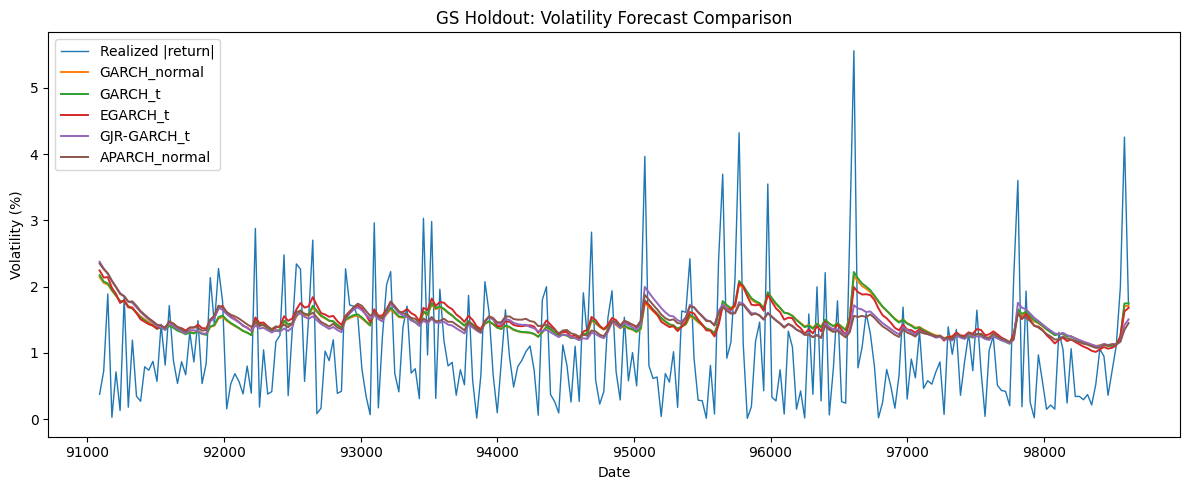


Processing HON


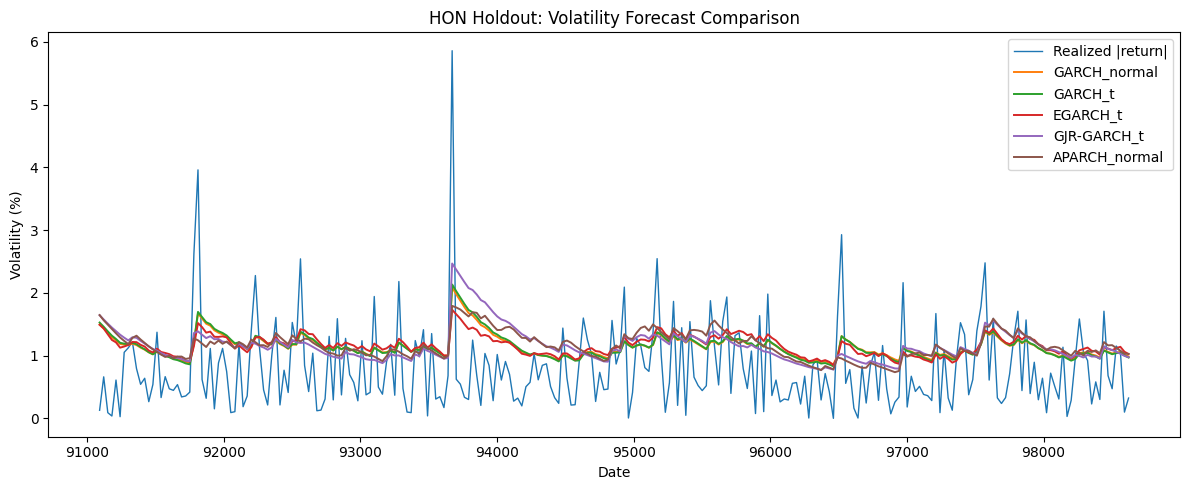


Processing PG


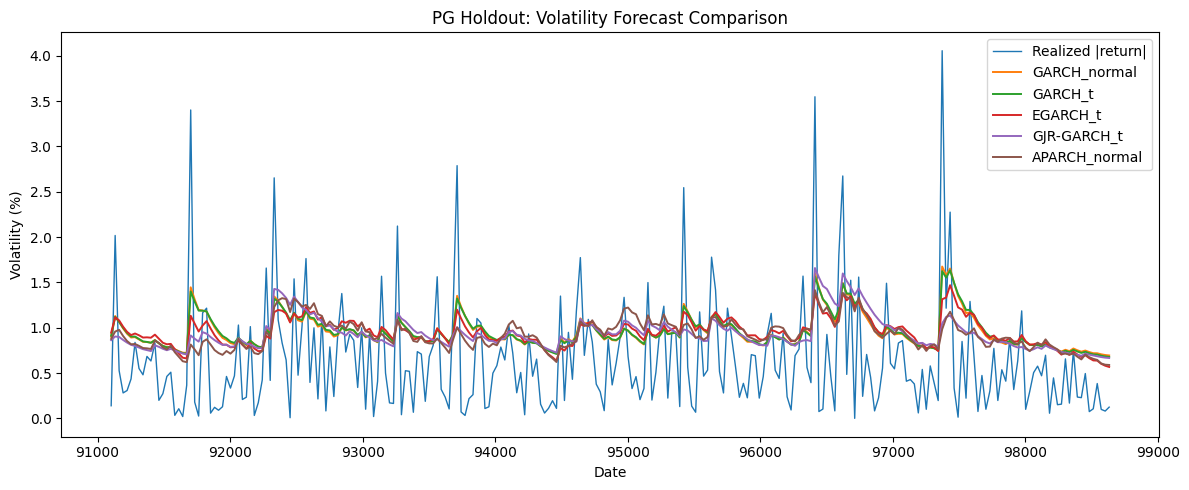


Processing JPM


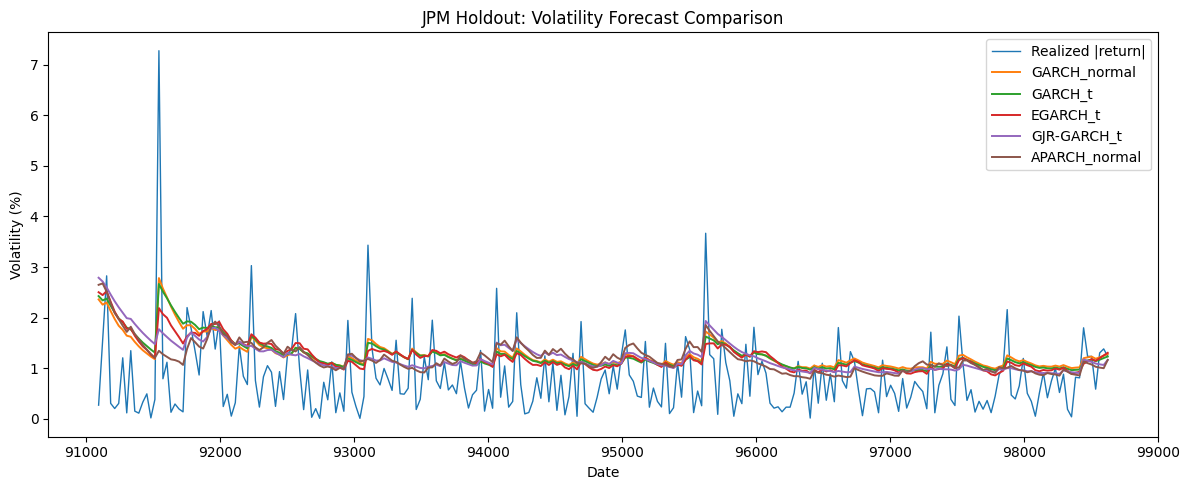


Processing MSFT


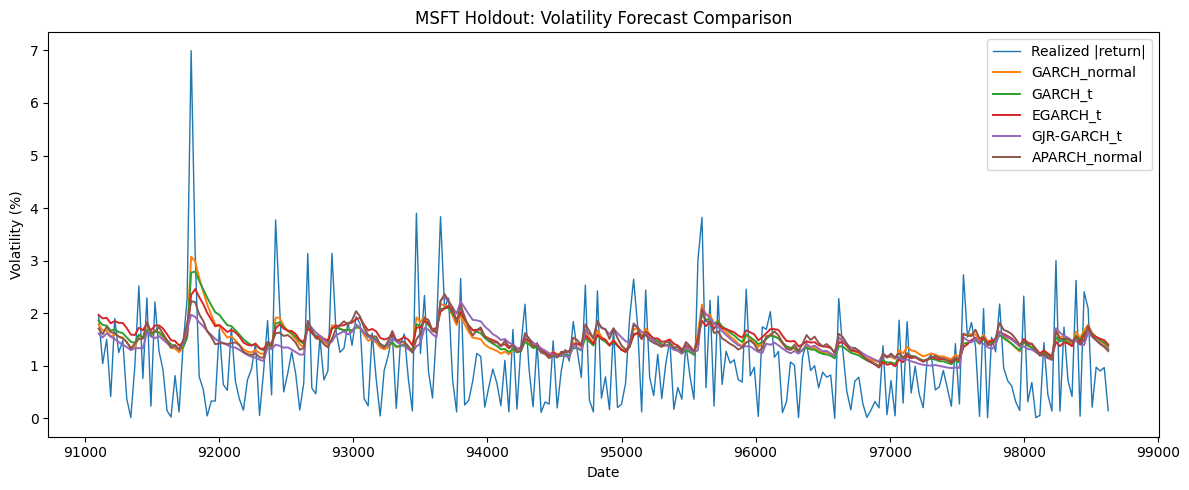

In [ ]:
for ticker in top_5_tickers:

    print(f"\nProcessing {ticker}")

    filtered_data = data[data['Ticker'] == ticker]
    y_all = (filtered_data["log_ret"] * 100).copy()

    split_idx = len(y_all) - 252
    y_train = y_all.iloc[:split_idx]
    y_test  = y_all.iloc[split_idx:]

    test_dates = y_test.index

    # Choose distribution
    dist_type = "t" if ticker == "GS" else "normal"

    # Define models
    models = {
        "GARCH_normal": arch_model(y_all, mean="Constant", vol="GARCH",
                                   p=1, q=1, dist="normal", rescale=False),
        "GARCH_t": arch_model(y_all, mean="Constant", vol="GARCH",
                              p=1, q=1, dist="t", rescale=False),
        "EGARCH_t": arch_model(y_all, mean="Constant", vol="EGARCH",
                               p=1, q=1, dist="t", rescale=False),
        "GJR-GARCH_t": arch_model(y_all, mean="Constant", vol="GARCH",
                                  p=1, o=1, q=1, dist="t", rescale=False),
        "APARCH_normal" : arch_model(y_all, mean='Constant', vol='APARCH',
                                     p=1, o=1, q=1, dist='normal', rescale=False
        ),
    }

    results = {}

    # Fit models
    for name, model in models.items():
        res = model.fit(last_obs=split_idx - 1, disp="off")
        results[name] = res

    # Forecast on holdout
    forecast_vol = {}

    for name, res_i in results.items():
        f_i = res_i.forecast(horizon=1, start=split_idx, reindex=True)
        vf_i = f_i.variance["h.1"].reindex(test_dates)
        forecast_vol[name] = np.sqrt(vf_i)

    forecast_vol_df = pd.DataFrame(forecast_vol).dropna()
    forecast_vol_df["Realized |return|"] = np.abs(y_test).reindex(forecast_vol_df.index)

    # Plot
    plt.figure(figsize=(12,5))

    plt.plot(
        forecast_vol_df.index,
        forecast_vol_df["Realized |return|"],
        linewidth=1.0,
        label="Realized |return|"
    )

    for model_name in results.keys():
        plt.plot(
            forecast_vol_df.index,
            forecast_vol_df[model_name],
            linewidth=1.4,
            label=model_name
        )

    plt.title(f"{ticker} Holdout: Volatility Forecast Comparison")
    plt.xlabel("Date")
    plt.ylabel("Volatility (%)")
    plt.legend()
    plt.tight_layout()
    plt.show()

### 30-Day Forecast

ALL STOCKS USE THE GJR-GARCH-t MODEL FOR FORECASTS.


Forecasting GS


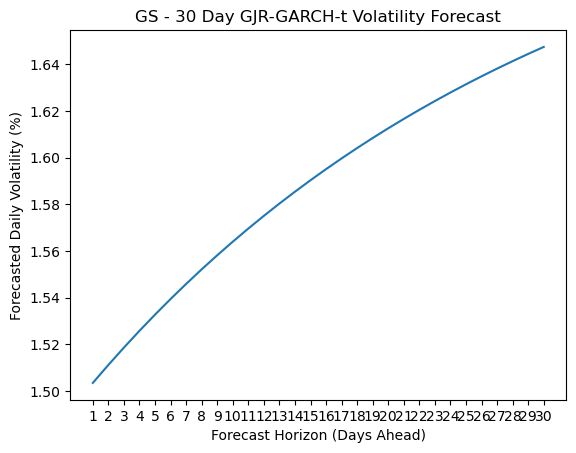


Forecasting HON


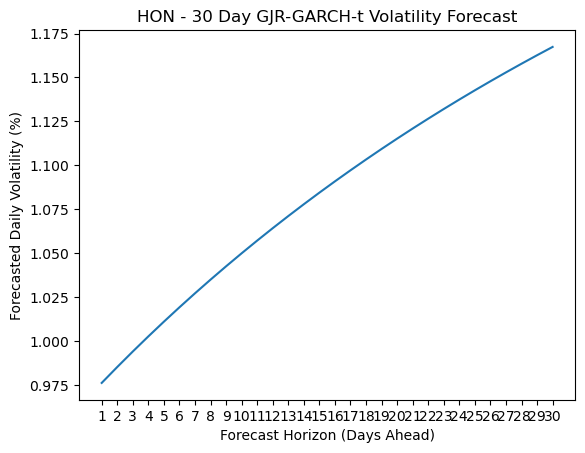


Forecasting PG


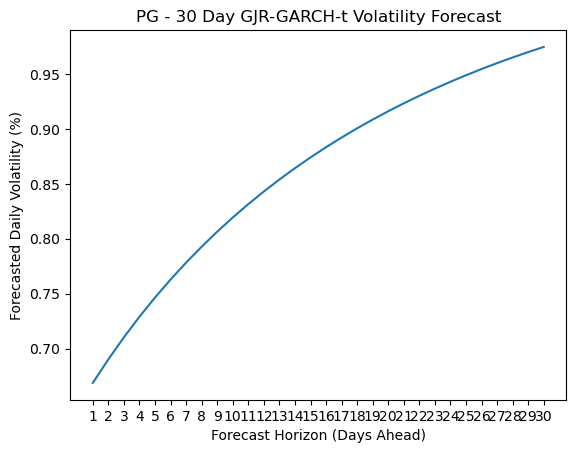


Forecasting JPM


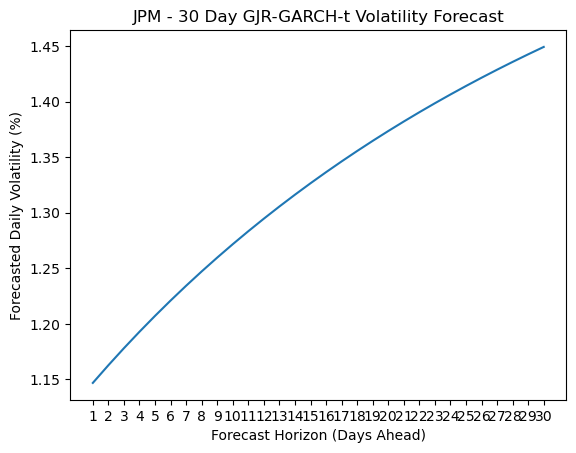


Forecasting MSFT


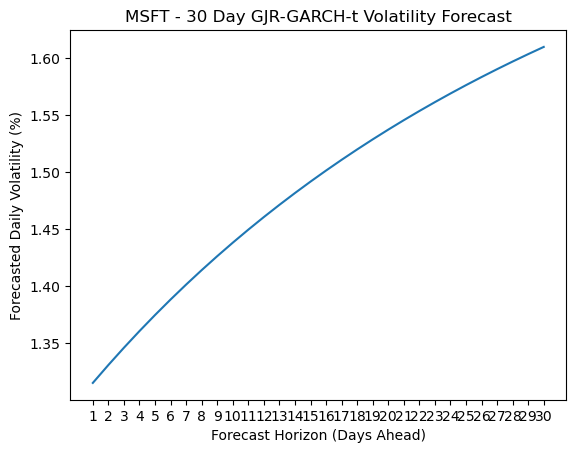

In [7]:
forecast_horizon = 30

vol_forecasts = {}

for ticker in top_5_tickers:

    print(f"\nForecasting {ticker}")

    filtered_data = data[data['Ticker'] == ticker]
    y = (filtered_data["log_ret"] * 100).copy()

    # GJR-GARCH(1,1) with Student-t errors
    model = arch_model(
        y,
        mean="Constant",
        vol="GARCH",
        p=1,
        o=1,          # <-- GJR asymmetry term
        q=1,
        dist="t",     # <-- Student-t errors
        rescale=False
    )

    # Fit on full dataset
    res = model.fit(disp="off")

    # 30-day ahead forecast
    forecast = res.forecast(horizon=forecast_horizon)

    # Get variance forecast (last row contains forward forecast)
    variance_f = forecast.variance.iloc[-1]

    # Convert to volatility
    volatility_f = np.sqrt(variance_f)

    vol_forecasts[ticker] = volatility_f

    # Convert forecast index to 1..30
    forecast_steps = np.arange(1, forecast_horizon + 1)

    # Plot forecasts
    plt.figure()
    plt.plot(forecast_steps, volatility_f.values)
    plt.title(f"{ticker} - 30 Day GJR-GARCH-t Volatility Forecast")
    plt.xlabel("Forecast Horizon (Days Ahead)")
    plt.ylabel("Forecasted Daily Volatility (%)")
    plt.xticks(forecast_steps)
    plt.show()

### Ranking Stocks

In [8]:
# Producing key parameters to evaluate stock sensitivity

summary_rows = []

for ticker in top_5_tickers:

    filtered_data = data[data['Ticker'] == ticker]
    y = (filtered_data["log_ret"] * 100).copy()

    # GJR-GARCH(1,1) with Student-t errors
    model = arch_model(
        y,
        mean="Constant",
        vol="GARCH",
        p=1,
        o=1,          # <-- GJR asymmetry term
        q=1,
        dist="t",
        rescale=False
    )

    res = model.fit(disp="off")

    # Extract parameters
    p = res.params

    omega   = p.get("omega", np.nan)
    alpha1  = p.get("alpha[1]", np.nan)
    gamma1  = p.get("gamma[1]", np.nan)   # <-- asymmetry
    beta1   = p.get("beta[1]", np.nan)
    nu      = p.get("nu", np.nan)

    # GJR persistence formula
    persistence = alpha1 + beta1 + (gamma1 / 2)

    summary_rows.append({
        "Ticker": ticker,
        "omega": omega,
        "alpha1 (shock sensitivity)": alpha1,
        "gamma1 (leverage effect)": gamma1,
        "beta1": beta1,
        "alpha+beta+gamma/2 (persistence)": persistence,
        "nu (t-dist df)": nu
    })

param_df = pd.DataFrame(summary_rows).set_index("Ticker")

param_df.round(4)

,omega,alpha1 (shock sensitivity),gamma1 (leverage effect),beta1,alpha+beta+gamma/2 (persistence),nu (t-dist df)
Ticker,,,,,,
GS,0.0913,0.0394,0.0847,0.8881,0.9699,6.0785
HON,0.0339,0.0134,0.1284,0.9055,0.9831,5.5332
PG,0.0475,0.0225,0.1253,0.8740,0.9592,4.4573
JPM,0.0669,0.0202,0.1406,0.8866,0.9771,5.6256
MSFT,0.0854,0.0273,0.1452,0.8748,0.9747,4.7634
